In [5]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
import contextlib
import copy
import io
import os
import queue
import threading
from datetime import date
from itertools import product
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
from sklearn.metrics import root_mean_squared_error, r2_score

from aquacrop import AquaCrop, Crop, Soil, Weather
from aquacrop_slovenia import config
from aquacrop_slovenia.diagnostics import nse, kge, mkge, kge_r, kge_beta, kge_alpha, mkge_alpha
from aquacrop_slovenia.plots import plot_yield_timeseries_comparison, plot_yield_scatter, plot_yield_timeseries_residuals
from aquacrop_slovenia.reading_data import get_yield, get_yield_for_comparison, get_co2_for_aquacrop, get_station_weather
from aquacrop_slovenia.parameter_defaults_jablje import (
    jablje_soil_layers,
    jablje_curve_number,
    jablje_readily_evaporable_water,
    jablje_maize_params,
    jablje_optimal_management,
    jablje_initial_cond,
    jablje_groundwater,
)

In [7]:
LOCATION = "jablje"
MAX_WORKERS = os.cpu_count()

simulation_periods = [
    {
        "start_date": date(year, 1, 1),
        "end_date": date(year, 10, 10),
        "planting_date": date(year, 5, 3),
        "is_seeding_year": True,
    }
    for year in range(1993, 2024)
    if year not in [2017]
]

temperatures, eto, rain = get_station_weather(8)
historical_co2 = get_co2_for_aquacrop("historical")

weather = Weather(
    location=LOCATION,
    temperatures=temperatures,
    eto_values=eto,
    rainfall_values=rain,
    record_type=1,
    first_day=1,
    first_month=1,
    first_year=1993,
    co2_records=historical_co2,
)

soil = Soil(
    name=f"{LOCATION} soil",
    description=f"{LOCATION} loamy sand soil",
    soil_layers=jablje_soil_layers,
    curve_number=jablje_curve_number,
    readily_evaporable_water=jablje_readily_evaporable_water,
)

observed_yield = get_yield_for_comparison(LOCATION, "biomass", "A", "N3")

INTEGER_PARAMS = {name for name, val in jablje_maize_params.items() if isinstance(val, int)}

In [8]:
# Parameters to search and their grid values (bounds from Optimization Jablje)
grid_params = {
    #"harvest_index":        np.linspace(0.46, 0.56, 6),
    "gdd_senescence":       np.linspace(1000, 1150, 5),
    "gdd_maturity":         np.linspace(1200, 1400, 5),
    "gdd_flowering":        np.linspace(480, 530, 5),
    "gdd_flowering_length": np.linspace(130, 170, 3),
    "max_canopy_cover":     np.linspace(0.85, 0.95, 5),
    #"min_rooting_depth":    np.linspace(0.2, 0.4, 3),
    #"max_rooting_depth":    np.linspace(1.8, 2.5, 3),
}

param_names = list(grid_params.keys())
grid_combinations = list(product(*grid_params.values()))

grid_shape = " x ".join(str(len(v)) for v in grid_params.values())
print(f"Grid: {grid_shape} = {len(grid_combinations):,} combinations")
print(f"Workers: {MAX_WORKERS}")

Grid: 5 x 5 x 5 x 5 = 625 combinations
Workers: 28


In [9]:
# Pre-create one working directory per worker to avoid conflicts
worker_dirs = []
for i in range(MAX_WORKERS):
    d = config.RAMDISK_DIR / f"grid_jablje_{i}"
    d.mkdir(parents=True, exist_ok=True)
    worker_dirs.append(d)

dir_queue = queue.Queue()
for d in worker_dirs:
    dir_queue.put(d)

print(f"Worker directories: {[str(d) for d in worker_dirs]}")

Worker directories: ['E:aquacrop\\grid_jablje_0', 'E:aquacrop\\grid_jablje_1', 'E:aquacrop\\grid_jablje_2', 'E:aquacrop\\grid_jablje_3', 'E:aquacrop\\grid_jablje_4', 'E:aquacrop\\grid_jablje_5', 'E:aquacrop\\grid_jablje_6', 'E:aquacrop\\grid_jablje_7', 'E:aquacrop\\grid_jablje_8', 'E:aquacrop\\grid_jablje_9', 'E:aquacrop\\grid_jablje_10', 'E:aquacrop\\grid_jablje_11', 'E:aquacrop\\grid_jablje_12', 'E:aquacrop\\grid_jablje_13', 'E:aquacrop\\grid_jablje_14', 'E:aquacrop\\grid_jablje_15', 'E:aquacrop\\grid_jablje_16', 'E:aquacrop\\grid_jablje_17', 'E:aquacrop\\grid_jablje_18', 'E:aquacrop\\grid_jablje_19', 'E:aquacrop\\grid_jablje_20', 'E:aquacrop\\grid_jablje_21', 'E:aquacrop\\grid_jablje_22', 'E:aquacrop\\grid_jablje_23', 'E:aquacrop\\grid_jablje_24', 'E:aquacrop\\grid_jablje_25', 'E:aquacrop\\grid_jablje_26', 'E:aquacrop\\grid_jablje_27']


In [10]:
def evaluate_params(param_values):
    """Run one grid point and return parameter values + all scores."""
    working_dir = dir_queue.get()
    try:
        params = copy.deepcopy(jablje_maize_params)
        for name, val in zip(param_names, param_values):
            params[name] = int(round(val)) if name in INTEGER_PARAMS else float(val)

        crop = Crop(
            name=f"{LOCATION} maize",
            description="grid search",
            params=params,
        )

        simulation = AquaCrop(
            simulation_periods=simulation_periods,
            crop=crop,
            soil=soil,
            management=jablje_optimal_management,
            initial_conditions=jablje_initial_cond,
            climate=weather,
            ground_water=jablje_groundwater,
            working_dir=working_dir,
            need_daily_output=False,
            need_seasonal_output=True,
            need_harvest_output=False,
            need_evaluation_output=False,
        )

        try:
            with contextlib.redirect_stdout(io.StringIO()):
                results = simulation.run()
        except Exception:
            nan_row = {**dict(zip(param_names, param_values))}
            nan_row.update({s: np.nan for s in ["rmse", "r2", "nse", "kge", "mkge"]})
            return nan_row

        seasonal = (
            results["season"][["Year1", "BioMass"]]
            .rename(columns={"Year1": "year", "BioMass": "yield_modeled"})
        )
        merged = observed_yield.merge(seasonal, on="year")
        y_obs = merged["yield"].values
        y_mod = merged["yield_modeled"].values

        return {
            **dict(zip(param_names, param_values)),
            "rmse":  root_mean_squared_error(y_obs, y_mod),
            "r2":    r2_score(y_obs, y_mod),
            "nse":   nse(y_mod, y_obs),
            "kge":   kge(y_mod, y_obs),
            "mkge":  mkge(y_mod, y_obs),
            "kge_r": kge_r(y_mod, y_obs),
            "kge_beta": kge_beta(y_mod, y_obs),
            "kge_alpha": kge_alpha(y_mod, y_obs),
            "mkge_alpha": mkge_alpha(y_mod, y_obs)
        }
    finally:
        dir_queue.put(working_dir)

360 simulacij / 1 minuto

In [47]:
total = len(grid_combinations)
results_list = []

print(f"Running {total:,} simulations with {MAX_WORKERS} workers...")
print(f"Approximate running time: {total // 360} min")

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = [executor.submit(evaluate_params, combo) for combo in grid_combinations]
    for future in as_completed(futures):
        results_list.append(future.result())

results_df = pd.DataFrame(results_list).sort_values("rmse").reset_index(drop=True)
print(f"\nComplete. Failed runs: {results_df['rmse'].isna().sum()}")

In [48]:
output_path = config.RESULTS_DIR / "grid_search_jablje_6_biomass.pkl"
results_df.to_pickle(output_path)
print(f"Saved {len(results_df):,} rows to {output_path}")

In [49]:
print("Top 20 by RMSE:")
results_df

,gdd_senescence,gdd_maturity,gdd_flowering,max_canopy_cover,rmse,r2,nse,kge,mkge,kge_r,kge_beta,kge_alpha,mkge_alpha
0,1000.0,1200.0,480.0,0.850,4.483641,-0.066297,-0.066297,-0.226430,-0.233334,0.097682,1.063056,0.171762,0.161574
1,1000.0,1200.0,492.5,0.850,4.542452,-0.094453,-0.094453,-0.228648,-0.236719,0.094092,1.074054,0.173307,0.161358
2,1000.0,1250.0,480.0,0.850,4.567173,-0.106398,-0.106398,-0.210237,-0.219117,0.123216,1.082150,0.169834,0.156942
3,1000.0,1200.0,480.0,0.875,4.580289,-0.112762,-0.112762,-0.223583,-0.232498,0.100128,1.081386,0.174916,0.161752
4,1000.0,1350.0,480.0,0.850,4.580914,-0.113065,-0.113065,-0.209212,-0.218336,0.125141,1.084640,0.169548,0.156317
...,...,...,...,...,...,...,...,...,...,...,...,...,...
620,1150.0,1400.0,530.0,0.925,7.809022,-2.234520,-2.234520,-0.196684,-0.232718,0.184092,1.358036,0.201153,0.148121
621,1150.0,1400.0,505.0,0.950,7.831567,-2.253223,-2.253223,-0.195680,-0.231959,0.185523,1.359552,0.201878,0.148488
622,1150.0,1350.0,530.0,0.950,7.835634,-2.256602,-2.256602,-0.194760,-0.230443,0.191705,1.360020,0.197195,0.144994
623,1150.0,1400.0,517.5,0.950,8.008357,-2.401758,-2.401758,-0.197538,-0.234861,0.186319,1.371063,0.203550,0.148462


In [50]:
pd.DataFrame(results_list).sort_values("kge_r").reset_index(drop=True)

,gdd_senescence,gdd_maturity,gdd_flowering,max_canopy_cover,rmse,r2,nse,kge,mkge,kge_r,kge_beta,kge_alpha,mkge_alpha
0,1150.0,1200.0,492.5,0.925,5.267909,-0.471950,-0.471950,-0.232735,-0.250037,0.089671,1.163142,0.184941,0.159001
1,1150.0,1200.0,492.5,0.900,5.143867,-0.403447,-0.403447,-0.232450,-0.248480,0.089734,1.150884,0.182943,0.158958
2,1150.0,1200.0,492.5,0.850,4.862003,-0.253854,-0.253854,-0.231578,-0.244391,0.090557,1.119902,0.178221,0.159140
3,1112.5,1200.0,492.5,0.900,5.102461,-0.380943,-0.380943,-0.231298,-0.246935,0.090819,1.146694,0.182708,0.159334
4,1112.5,1200.0,492.5,0.925,5.224142,-0.447593,-0.447593,-0.231449,-0.248365,0.090890,1.158955,0.184697,0.159365
...,...,...,...,...,...,...,...,...,...,...,...,...,...
620,1150.0,1350.0,517.5,0.950,7.696709,-2.142148,-2.142148,-0.192690,-0.227490,0.192675,1.350953,0.195284,0.144553
621,1150.0,1350.0,480.0,0.875,6.436050,-1.197128,-1.197128,-0.177585,-0.204556,0.192994,1.264121,0.184102,0.145637
622,1150.0,1350.0,530.0,0.875,7.062067,-1.645332,-1.645332,-0.184327,-0.215313,0.193527,1.308394,0.189368,0.144733
623,1150.0,1350.0,505.0,0.875,6.793407,-1.447889,-1.447889,-0.181664,-0.210865,0.193589,1.289736,0.186315,0.144460


In [51]:
score_cols = ["rmse", "r2", "nse", "kge", "mkge"]
ascending = {"rmse": True, "r2": False, "nse": False, "kge": False, "mkge": False}

for metric in score_cols:
    best = results_df.sort_values(metric, ascending=ascending[metric]).iloc[0]
    param_str = ", ".join(f"{p}={best[p]:.4f}" for p in param_names)
    print(f"\nBest {metric.upper():5s}: {best[metric]:.4f}")
    print(f"  {param_str}")

In [52]:
best = {}

In [53]:
# Re-run with the best parameter set (lowest RMSE) to get full seasonal results for plotting
best = results_df.iloc[-1]

best_params = copy.deepcopy(jablje_maize_params)
for name in param_names:
    val = best[name]
    best_params[name] = int(round(val)) if name in INTEGER_PARAMS else float(val)

best_crop = Crop(
    name=f"{LOCATION} maize (best grid)",
    description="best grid search parameters",
    params=best_params,
)

best_dir = config.RAMDISK_DIR / "grid_jablje_best"
best_dir.mkdir(parents=True, exist_ok=True)

best_simulation = AquaCrop(
    simulation_periods=simulation_periods,
    crop=best_crop,
    soil=soil,
    management=jablje_optimal_management,
    initial_conditions=jablje_initial_cond,
    climate=weather,
    #ground_water=jablje_groundwater,
    working_dir=best_dir,
    need_daily_output=False,
    need_seasonal_output=True,
    need_harvest_output=False,
    need_evaluation_output=False,
)

best_results = best_simulation.run()
best_seasonal = best_results["season"]

print(f"RMSE:  {best['rmse']:.4f}")
print(f"R2:    {best['r2']:.4f}")
print(f"NSE:   {best['nse']:.4f}")
print(f"KGE:   {best['kge']:.4f}")
print(f"mKGE:  {best['mkge']:.4f}")

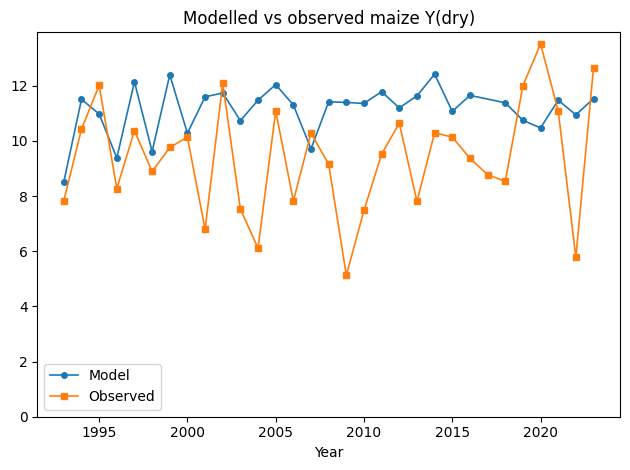

In [54]:
plot_yield_timeseries_comparison(best_seasonal, get_yield(LOCATION, "grain", "A", "N3"), "Y(dry)")

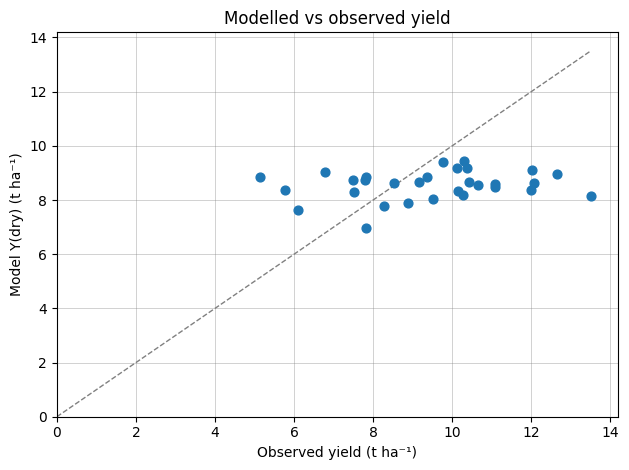

In [27]:
plot_yield_scatter(best_seasonal, get_yield(LOCATION, "grain", "A", "N3"))

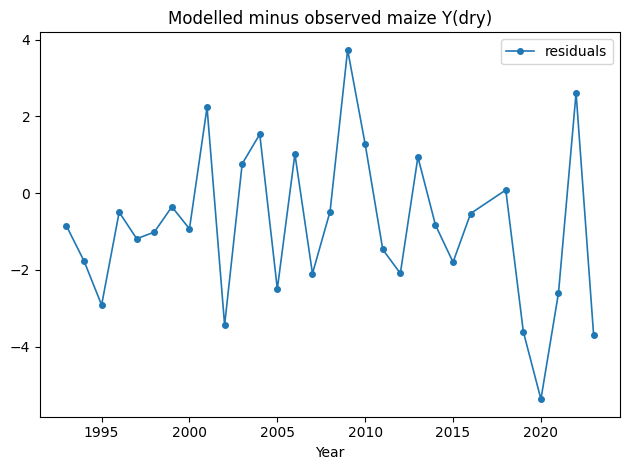

In [28]:
plot_yield_timeseries_residuals(best_seasonal, get_yield_for_comparison(LOCATION, "grain", "A", "N3"), "Y(dry)")

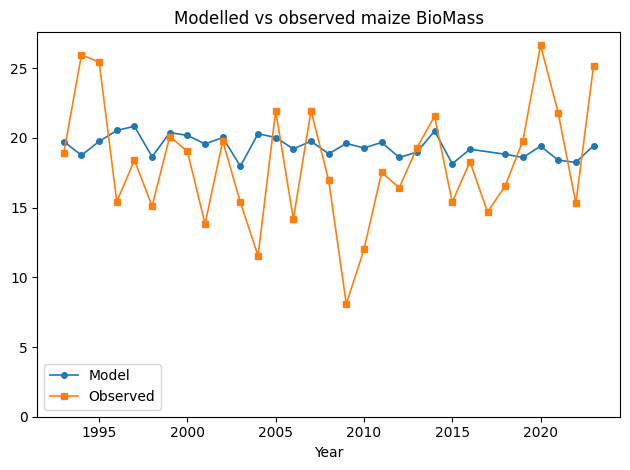

In [29]:
plot_yield_timeseries_comparison(best_seasonal, get_yield(LOCATION, "biomass", "A", "N3"), "BioMass")